In [18]:
import os
import random
from torchvision.transforms.functional import pil_to_tensor, to_pil_image
import torch
from PIL import Image

from datasets import load_dataset
from pipeline import InferencePipeline
from utils.cutting import irregular_cut

os.chdir("..")

In [2]:
dataset = load_dataset(
    "Artificio/WikiArt_Full",
)["train"]

pipeline = InferencePipeline()

Using device: cuda
Loading models...
Models loaded successfully!


## Original image

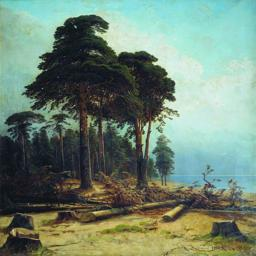

In [3]:
random_idx = random.randint(0, len(dataset) - 1)
random_image = dataset[random_idx]["image"]
random_image

## Corrupted image

In [4]:
tensor_image = pil_to_tensor(random_image)
cut_image_tensor = irregular_cut(tensor_image)

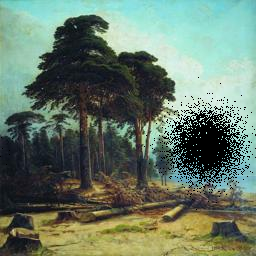

In [5]:
cut_image = to_pil_image(cut_image_tensor)
cut_image

## Latent space

In [6]:
cut_image_tensor = pipeline.preprocess(cut_image)

with torch.no_grad():
    latent_space = pipeline.autoencoder.encode(cut_image_tensor)

## Cluster

In [7]:
cluster_id = pipeline.predict_cluster(latent_space)
print(f"Predicted cluster ID: {cluster_id}")

Predicted cluster ID: 0


## Inpainted image with superresolution

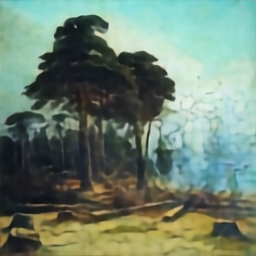

In [30]:
with torch.no_grad():
    inpainted_latent = pipeline.inpainter(latent_space)
    output_image_tensor = pipeline.autoencoder.decode(inpainted_latent).squeeze(0)

output_image = to_pil_image(output_image_tensor)
output_image

## Superresolution

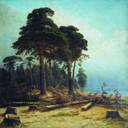

In [27]:
downscaled_image = random_image.resize((random_image.width // 2, random_image.height // 2), Image.Resampling.BICUBIC)
downscaled_image

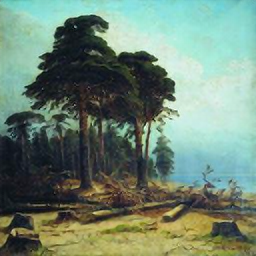

In [ ]:
downscaled_image_tensor = (pil_to_tensor(downscaled_image).float() / 255.0).to(pipeline.device)
with torch.no_grad():
    superresoluted_image_tensor = pipeline.superresolution(downscaled_image_tensor)

superresoluted_image = to_pil_image(superresoluted_image_tensor)
superresoluted_image